In [1]:
import seaborn as sns
import pandas as pd 
import matplotlib.pyplot as plt
df=sns.load_dataset('tips')
print(df.head())
print(df.shape)
print(df.info())


   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4
(244, 7)
<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB
None


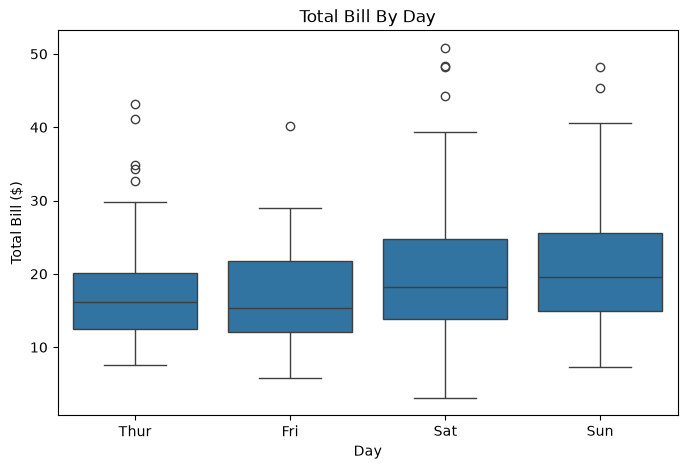

In [2]:
plt.figure(figsize=(8,5))
sns.boxplot(x='day',y='total_bill',data=df)
plt.title("Total Bill By Day")
plt.xlabel('Day')
plt.ylabel('Total Bill ($)')
plt.xticks(rotation=0)
plt.show()

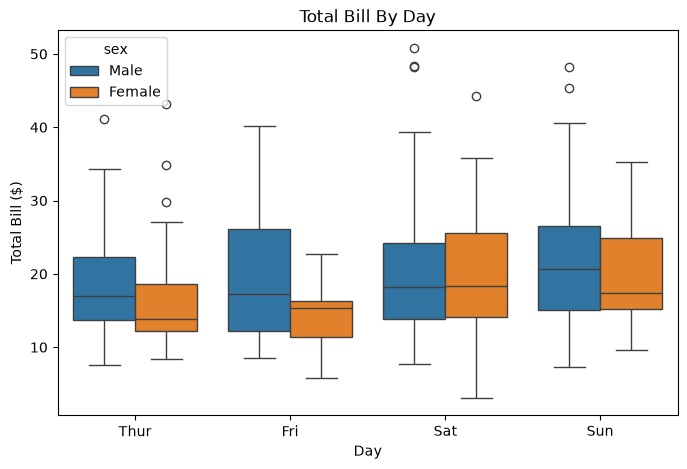

In [3]:
plt.figure(figsize=(8,5))
sns.boxplot(x='day',y='total_bill',hue='sex',data=df)
plt.title("Total Bill By Day")
plt.xlabel('Day')
plt.ylabel('Total Bill ($)')
plt.xticks(rotation=0)
plt.show()

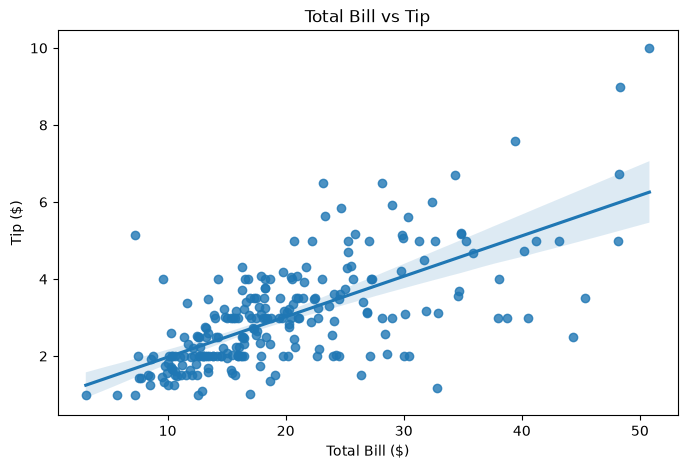

In [4]:
plt.figure(figsize=(8,5))
sns.regplot(x='total_bill', y='tip', data=df)
plt.title('Total Bill vs Tip')
plt.xlabel('Total Bill ($)')
plt.ylabel('Tip ($)')
plt.show()

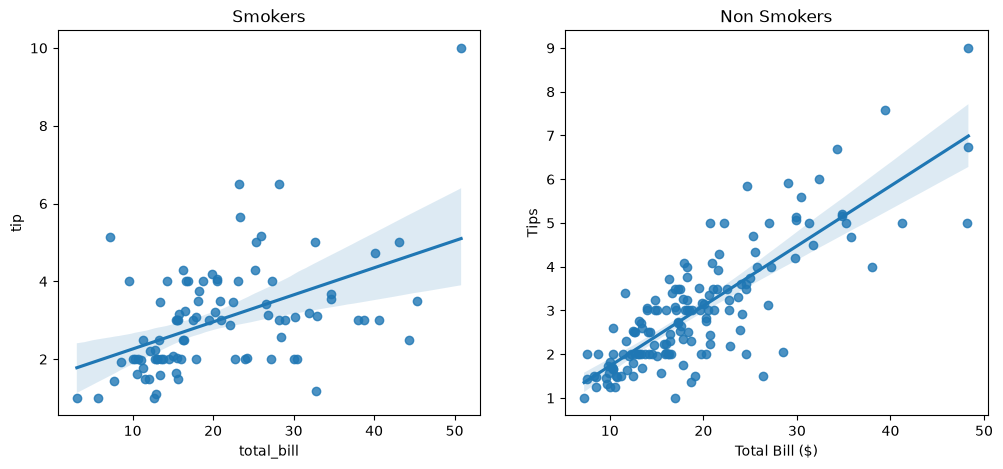

In [8]:
fig,axes=plt.subplots(1,2,figsize=(12,5))
sns.regplot(x='total_bill',y='tip',data=df[df['smoker']=='Yes'],ax=axes[0])
axes[0].set_title('Smokers')
sns.regplot(x='total_bill',y='tip',data=df[df['smoker']=='No'],ax=axes[1])
axes[1].set_title('Non Smokers')
plt.xlabel('Total Bill ($)')
plt.ylabel('Tips')
plt.show()

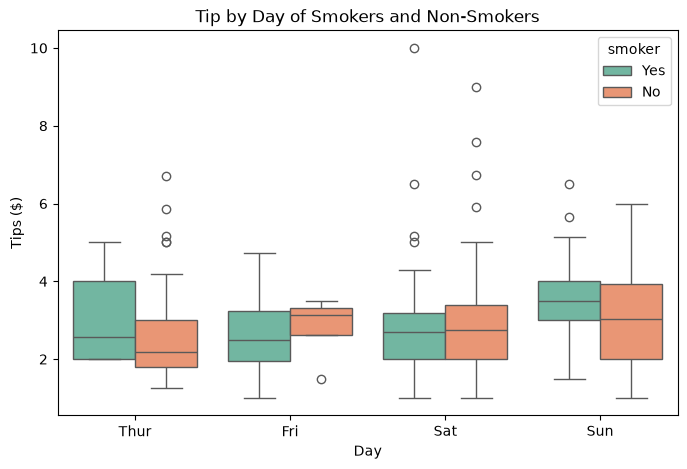

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
df=sns.load_dataset('tips')
plt.figure(figsize=(8,5))
sns.boxplot(x='day',y='tip',data=df,hue='smoker',palette='Set2')
plt.title('Tip by Day of Smokers and Non-Smokers')
plt.xlabel('Day')
plt.ylabel('Tips ($)')
plt.show()

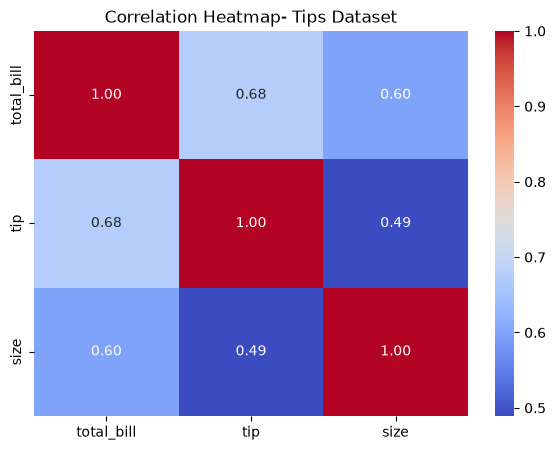

In [4]:
plt.figure(figsize=(7,5))
sns.heatmap(df.corr(numeric_only=True),annot=True,fmt='.2f',cmap='coolwarm')
plt.title('Correlation Heatmap- Tips Dataset')
plt.show()

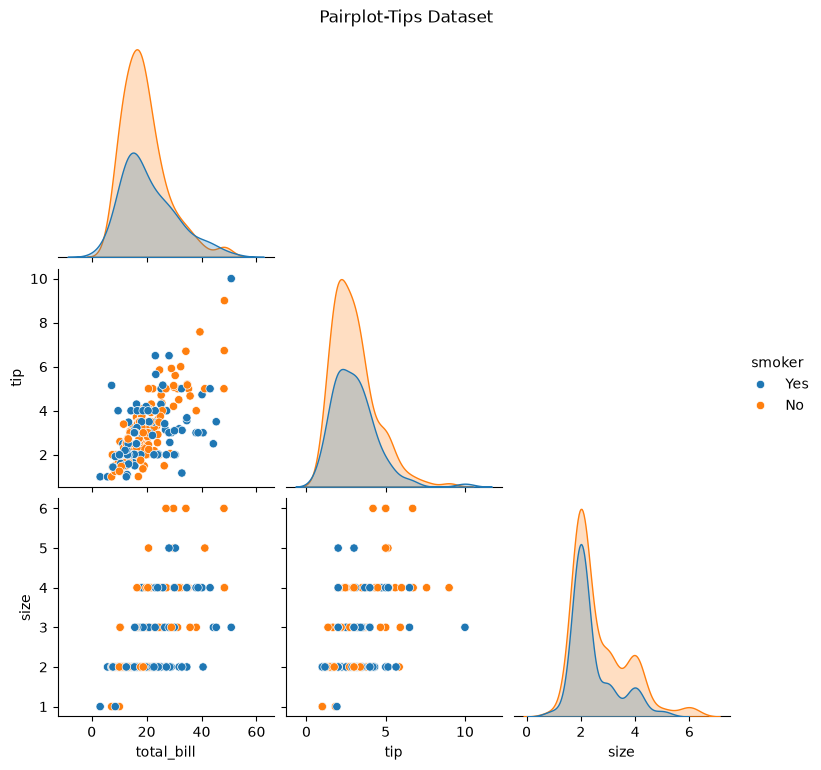

In [5]:
sns.pairplot(df,hue='smoker',corner='True')
plt.suptitle('Pairplot-Tips Dataset',y=1.02)
plt.show()

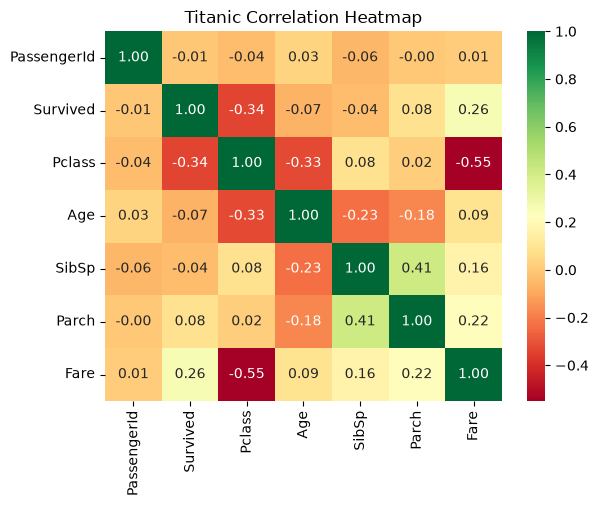

In [7]:
df=pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')
df=df.drop(columns=['Cabin'])
df['Age']=df['Age'].fillna(df['Age'].mean())
df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode()[0])
sns.heatmap(df.corr(numeric_only=True),annot=True,fmt='.2f',cmap='RdYlGn')
plt.title('Titanic Correlation Heatmap')
plt.show()

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
df=sns.load_dataset('tips')
print(df['tip'].corr(df['size']))
      

0.48929877523035786


In [3]:
from pandasql import sqldf
import warnings 
warnings.filterwarnings('ignore')
df=pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')
query="""
SELECT * FROM df LIMIT 5
"""
result=sqldf(query)
print(result)


   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [4]:
query="""
SELECT Name, Sex, Age, Survived 
FROM df
WHERE Survived==1
"""
result=sqldf(query)
print(result)

                                                  Name     Sex   Age  Survived
0    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0         1
1                               Heikkinen, Miss. Laina  female  26.0         1
2         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0         1
3    Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)  female  27.0         1
4                  Nasser, Mrs. Nicholas (Adele Achem)  female  14.0         1
..                                                 ...     ...   ...       ...
337                   Najib, Miss. Adele Kiamie "Jane"  female  15.0         1
338      Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)  female  56.0         1
339       Shelley, Mrs. William (Imanita Parrish Hall)  female  25.0         1
340                       Graham, Miss. Margaret Edith  female  19.0         1
341                              Behr, Mr. Karl Howell    male  26.0         1

[342 rows x 4 columns]


In [5]:
query="""SELECT Pclass, AVG(Fare) as avg_fare, COUNT(*) as total_passengers
FROM df
GROUP BY Pclass 
ORDER BY avg_fare DESC
"""
result=sqldf(query)
print(result)

   Pclass   avg_fare  total_passengers
0       1  84.154687               216
1       2  20.662183               184
2       3  13.675550               491


In [6]:
query="""SELECT Sex, AVG(Survived)*100 as survival_rate
FROM df
GROUP BY Sex
"""
result=sqldf(query)
print(result)

      Sex  survival_rate
0  female      74.203822
1    male      18.890815


In [3]:
import pandas as pd 
from pandasql import sqldf
import warnings
df=pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')
warnings.filterwarnings('ignore')
query='''SELECT Pclass, Sex, AVG(Survived)*100 as Survival_rate
FROM df
GROUP BY Pclass, Sex
ORDER BY Survival_rate DESC
'''
result=sqldf(query)
print(result)


   Pclass     Sex  Survival_rate
0       1  female      96.808511
1       2  female      92.105263
2       3  female      50.000000
3       1    male      36.885246
4       2    male      15.740741
5       3    male      13.544669


In [4]:
passengers = pd.DataFrame({
    'passenger_id': [1, 2, 3, 4, 5],
    'name': ['Alice', 'Bob', 'Charlie', 'Diana', 'Eve'],
    'class': [1, 2, 3, 1, 2]
})

tickets = pd.DataFrame({
    'passenger_id': [1, 2, 3, 6],
    'fare': [150, 50, 10, 200]
})

print(passengers)
print(tickets)

   passenger_id     name  class
0             1    Alice      1
1             2      Bob      2
2             3  Charlie      3
3             4    Diana      1
4             5      Eve      2
   passenger_id  fare
0             1   150
1             2    50
2             3    10
3             6   200


In [5]:
# INNER JOIN
query = """
SELECT p.name, p.class, t.fare
FROM passengers p
INNER JOIN tickets t ON p.passenger_id = t.passenger_id
"""
print("INNER JOIN:")
print(sqldf(query))

INNER JOIN:
      name  class  fare
0    Alice      1   150
1      Bob      2    50
2  Charlie      3    10


In [6]:
# LEFT JOIN
query = """
SELECT p.name, p.class, t.fare
FROM passengers p
LEFT JOIN tickets t ON p.passenger_id = t.passenger_id
"""
print("LEFT JOIN:")
print(sqldf(query))

LEFT JOIN:
      name  class   fare
0    Alice      1  150.0
1      Bob      2   50.0
2  Charlie      3   10.0
3    Diana      1    NaN
4      Eve      2    NaN


In [ ]:
query="""SELECT p.name,p.class,t.fare
FROM passengers p
LEFT JOIN tickets t ON t."""